# 📄 DocTrust — Integrated Academic Writing Assistance System

**Project:** DocTrust  
**Supervised by:** Dr. Haithem Ghallab  
**Team:** Ahmed Khaled, Sarah Mohamed, Saif Tarek, Abdul Rahman Khalid, Omar Essam, Mohamed Mahmoud, Nesma Mohamed

---

## 🎯 Project Overview

This notebook implements the three core NLP modules of the **DocTrust** platform:

| Module | Model Used | Purpose |
|---|---|---|
| **Text Summarization** | `facebook/bart-large-cnn` | Generate concise abstractive summaries |
| **Text Paraphrasing** | `Vamsi/T5_Paraphrase_Paws` | Rephrase text while preserving meaning |
| **Plagiarism Detection** | `all-MiniLM-L6-v2` (SBERT) | Detect semantic similarity against a corpus |

---

### 📋 Notebook Structure
1. Library Installation
2. Dataset Loading & Exploration
3. Text Preprocessing Pipeline
4. Module 1 — Text Summarization (BART)
5. Module 2 — Text Paraphrasing (T5)
6. Module 3 — Plagiarism Detection (SBERT)
7. Evaluation Metrics (ROUGE + Cosine Similarity)
8. Integrated Pipeline Demo
9. Results & Analysis

---
## 📦 Section 1 — Library Installation

We install all required libraries:
- **transformers**: provides BART and T5 pre-trained models via HuggingFace
- **sentence-transformers**: provides SBERT (all-MiniLM-L6-v2) for semantic embeddings
- **rouge-score**: used to evaluate summarization quality
- **datasets**: used to load CNN/DailyMail benchmark dataset

In [ ]:
# Install all required dependencies
# transformers : HuggingFace pre-trained models (BART, T5)
# sentence-transformers : SBERT for semantic similarity
# rouge-score  : evaluation metric for summarization
# datasets     : load CNN/DailyMail benchmark
# faiss-cpu    : fast vector similarity search for plagiarism detection

!pip install transformers==4.41.2 sentence-transformers==2.7.0 \
             rouge-score datasets faiss-cpu -q


---
## 📂 Section 2 — Dataset Loading & Exploration

We use the **CNN/DailyMail** dataset (version 3.0.0), which is the standard benchmark for text summarization tasks.

- **`article`**: the full news article (used as model input)
- **`highlights`**: the reference human-written summary (used for ROUGE evaluation)

> We load only 10 samples for demonstration speed. In production, the full dataset would be used.

In [ ]:
from datasets import load_dataset

# Load CNN/DailyMail — standard benchmark dataset for summarization
# split='train[:10]' loads only 10 examples for fast demonstration
# In a full experiment, use 'test' split for proper evaluation
dataset = load_dataset("cnn_dailymail", "3.0.0", split="train[:10]")

print(f"Dataset loaded: {len(dataset)} samples")
print(f"Available fields: {list(dataset[0].keys())}")

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


Dataset loaded: 10 samples
Available fields: ['article', 'highlights', 'id']


In [ ]:
# Explore the structure of sample 0
# This helps us understand what the model receives as input
# and what the expected ground-truth output looks like

sample = dataset[0]

print("=" * 70)
print("ARTICLE (first 600 characters):")
print("=" * 70)
print(sample["article"][:600])

print("\n" + "=" * 70)
print("REFERENCE SUMMARY (ground truth):")
print("=" * 70)
print(sample["highlights"])

ARTICLE (first 600 characters):
LONDON, England (Reuters) -- Harry Potter star Daniel Radcliffe gains access to a reported £20 million ($41.1 million) fortune as he turns 18 on Monday, but he insists the money won't cast a spell on him. Daniel Radcliffe as Harry Potter in "Harry Potter and the Order of the Phoenix" To the disappointment of gossip columnists around the world, the young actor says he has no plans to fritter his cash away on fast cars, drink and celebrity parties. "I don't plan to be one of those people who, as soon as they turn 18, suddenly buy themselves a massive sports car collection or something similar," 

REFERENCE SUMMARY (ground truth):
Harry Potter star Daniel Radcliffe gets £20M fortune as he turns 18 Monday .
Young actor says he has no plans to fritter his cash away .
Radcliffe's earnings from first five Potter films have been held in trust fund .


---
## 🤖 Section 3 — Load All Models

We load **all three models upfront** before any function definitions.
This avoids `NameError` issues when functions reference models defined in later cells.

| Variable | Model | Purpose |
|---|---|---|
| `summarizer` | `facebook/bart-large-cnn` | Text summarization |
| `para_tokenizer` / `para_model` | `Vamsi/T5_Paraphrase_Paws` | Text paraphrasing |
| `embedder` | `all-MiniLM-L6-v2` | Semantic similarity (paraphrase eval + plagiarism) |

> ⚠️ **Run this cell before any other code cell.** All subsequent cells depend on these variables.


In [ ]:
import re
import numpy as np
from transformers import pipeline, AutoTokenizer, AutoModelForSeq2SeqLM
from sentence_transformers import SentenceTransformer
from sklearn.metrics.pairwise import cosine_similarity

# ── Module 1: BART — Text Summarization ──────────────────────────────────────
# Fine-tuned on CNN/DailyMail → generates abstractive summaries
# Reference: Chapter 3, Section 5 (Model Selection & Justification)
print('[1/3] Loading BART summarization model...')
summarizer = pipeline('summarization', model='facebook/bart-large-cnn')
print('      ✅ BART loaded.')

# ── Module 2: T5-PAWS — Text Paraphrasing ────────────────────────────────────
# Fine-tuned on PAWS dataset — understands 'paraphrase:' task prefix
# Reference: Chapter 3, Figure 17 (T5 Paraphrasing Module Architecture)
print('[2/3] Loading T5 paraphrasing model (Vamsi/T5_Paraphrase_Paws)...')
para_tokenizer = AutoTokenizer.from_pretrained('Vamsi/T5_Paraphrase_Paws')
para_model = AutoModelForSeq2SeqLM.from_pretrained('Vamsi/T5_Paraphrase_Paws')
print('      ✅ T5-PAWS loaded.')

# ── Module 3: SBERT — Semantic Embeddings ────────────────────────────────────
# Used for BOTH paraphrase quality evaluation AND plagiarism detection
# Generates 384-dimensional dense sentence embeddings
# Reference: Chapter 3, Section 5 & Figure 18
print('[3/3] Loading SBERT model (all-MiniLM-L6-v2)...')
embedder = SentenceTransformer('all-MiniLM-L6-v2')
print('      ✅ SBERT loaded.')

print('\n🎉 All models loaded! You can now run any cell below safely.')


[1/3] Loading BART summarization model...


You are using the default legacy behaviour of the <class 'transformers.models.t5.tokenization_t5.T5Tokenizer'>. This is expected, and simply means that the `legacy` (previous) behavior will be used so nothing changes for you. If you want to use the new behaviour, set `legacy=False`. This should only be set if you understand what it means, and thoroughly read the reason why this was added as explained in https://github.com/huggingface/transformers/pull/24565


      ✅ BART loaded.
[2/3] Loading T5 paraphrasing model (Vamsi/T5_Paraphrase_Paws)...
      ✅ T5-PAWS loaded.
[3/3] Loading SBERT model (all-MiniLM-L6-v2)...


/usr/local/lib/python3.12/dist-packages/huggingface_hub/file_download.py:949: FutureWarning: `resume_download` is deprecated and will be removed in version 1.0.0. Downloads always resume when possible. If you want to force a new download, use `force_download=True`.
  warnings.warn(


      ✅ SBERT loaded.

🎉 All models loaded! You can now run any cell below safely.


---
## 🔧 Section 4 — Text Preprocessing Pipeline

Before feeding text into any model, we apply a basic preprocessing pipeline:
- Remove excessive whitespace and newlines
- Truncate text to a manageable length (models have token limits)
- Optionally strip special characters

> BART handles most tokenization internally, but clean input improves output quality.


In [ ]:

def preprocess_text(text, max_chars=1500):
    """
    Clean and truncate input text before passing to the model.

    Args:
        text (str): Raw input text.
        max_chars (int): Maximum number of characters to keep.
                         BART supports up to ~1024 tokens ≈ 1500 characters.
    Returns:
        str: Cleaned and truncated text.
    """
    # Remove multiple consecutive whitespace/newlines
    text = re.sub(r'\s+', ' ', text).strip()

    # Truncate to max_chars to avoid exceeding the model's token limit
    text = text[:max_chars]

    return text

# Test preprocessing on dataset sample
raw_text = dataset[0]["article"]
clean_text = preprocess_text(raw_text)

print(f"Original length : {len(raw_text)} characters")
print(f"After preprocess: {len(clean_text)} characters")
print("\nCleaned text preview:")
print(clean_text[:300])

Original length : 2527 characters
After preprocess: 1500 characters

Cleaned text preview:
LONDON, England (Reuters) -- Harry Potter star Daniel Radcliffe gains access to a reported £20 million ($41.1 million) fortune as he turns 18 on Monday, but he insists the money won't cast a spell on him. Daniel Radcliffe as Harry Potter in "Harry Potter and the Order of the Phoenix" To the disappoi


---
## 📝 Section 5 — Module 1: Text Summarization (BART)

### Why BART?
As stated in the thesis (Chapter 3 — Model Selection & Justification), we use **BART (facebook/bart-large-cnn)** because:
- It is a denoising autoencoder pre-trained for sequence-to-sequence tasks
- Fine-tuned specifically on CNN/DailyMail → ideal for news summarization
- Generates **abstractive** summaries (not just copying sentences)
- Outperforms extractive methods (TextRank, TF-IDF) in semantic quality

### Generation Strategy: Beam Search
We compare `num_beams=2` vs `num_beams=6`:
- **Low beams (2):** Faster, slightly lower quality
- **High beams (6):** Slower, explores more candidate sequences → better quality


In [ ]:
# Confirm BART summarizer is ready (loaded in Section 3)
print('BART summarizer ready:', type(summarizer))


BART summarizer ready: <class 'transformers.pipelines.text2text_generation.SummarizationPipeline'>


In [ ]:
def summarize(text, max_length=120, min_length=40, num_beams=4):
    """
    Generate an abstractive summary using BART.

    Args:
        text (str): Input article text (already preprocessed).
        max_length (int): Maximum token length of the output summary.
        min_length (int): Minimum token length to avoid very short outputs.
        num_beams (int): Number of beams for beam search decoding.
                         Higher = better quality but slower.
    Returns:
        str: Generated summary text.
    """
    result = summarizer(
        text,
        max_length=max_length,
        min_length=min_length,
        num_beams=num_beams,
        do_sample=False  # deterministic output (beam search, not sampling)
    )
    return result[0]['summary_text']


# Test on sample 0
text = preprocess_text(dataset[0]["article"])

print("=" * 70)
print("INPUT ARTICLE (truncated):")
print("=" * 70)
print(text[:500])

print("\n" + "=" * 70)
print("GENERATED SUMMARY:")
print("=" * 70)
print(summarize(text))

print("\n" + "=" * 70)
print("REFERENCE SUMMARY (ground truth):")
print("=" * 70)
print(dataset[0]["highlights"])

INPUT ARTICLE (truncated):
LONDON, England (Reuters) -- Harry Potter star Daniel Radcliffe gains access to a reported £20 million ($41.1 million) fortune as he turns 18 on Monday, but he insists the money won't cast a spell on him. Daniel Radcliffe as Harry Potter in "Harry Potter and the Order of the Phoenix" To the disappointment of gossip columnists around the world, the young actor says he has no plans to fritter his cash away on fast cars, drink and celebrity parties. "I don't plan to be one of those people who, as s

GENERATED SUMMARY:
Harry Potter star Daniel Radcliffe turns 18 on Monday. He gains access to a reported £20 million ($41.1 million) fortune. Radcliffe's earnings from the first five Potter films have been held in a trust fund.

REFERENCE SUMMARY (ground truth):
Harry Potter star Daniel Radcliffe gets £20M fortune as he turns 18 Monday .
Young actor says he has no plans to fritter his cash away .
Radcliffe's earnings from first five Potter films have been held in trus

In [ ]:
# Compare effect of beam search on output quality
# num_beams=2 → fast, lower diversity
# num_beams=6 → slower, explores more candidates

text = preprocess_text(dataset[2]["article"])

summary_beam2 = summarize(text, num_beams=2)
summary_beam6 = summarize(text, num_beams=6)

print("=" * 70)
print("ORIGINAL ARTICLE (first 500 chars):")
print("=" * 70)
print(text[:500])

print("\n" + "=" * 70)
print("SUMMARY with num_beams=2 (faster):")
print("=" * 70)
print(summary_beam2)

print("\n" + "=" * 70)
print("SUMMARY with num_beams=6 (higher quality):")
print("=" * 70)
print(summary_beam6)

print("\n" + "=" * 70)
print("REFERENCE SUMMARY:")
print("=" * 70)
print(dataset[2]["highlights"])

ORIGINAL ARTICLE (first 500 chars):
MINNEAPOLIS, Minnesota (CNN) -- Drivers who were on the Minneapolis bridge when it collapsed told harrowing tales of survival. "The whole bridge from one side of the Mississippi to the other just completely gave way, fell all the way down," survivor Gary Babineau told CNN. "I probably had a 30-, 35-foot free fall. And there's cars in the water, there's cars on fire. The whole bridge is down." He said his back was injured but he determined he could move around. "I realized there was a school bus 

SUMMARY with num_beams=2 (faster):
Driver: "The whole bridge from one side of the Mississippi to the other just completely gave way" "I probably had a 30-, 35-foot free fall," says survivor Gary Babineau. "I realized there was a school bus right next to me," he says. Dr. John Hink rushed to the scene in 15 minutes.

SUMMARY with num_beams=6 (higher quality):
"The whole bridge from one side of the Mississippi to the other just completely gave way" "There's ca

---
## ✍️ Section 5 — Module 2: Text Paraphrasing (T5)

### Why T5 with PAWS fine-tuning?
As described in the thesis (Chapter 3, Figure 17), the paraphrasing module uses:
- **`Vamsi/T5_Paraphrase_Paws`** — a T5 model fine-tuned on **PAWS** (Paraphrase Adversaries from Word Scrambling)
- This model is specifically trained to rewrite text with different wording while preserving meaning
- The prefix `"paraphrase:"` tells T5 which task to perform (T5 is a text-to-text model)

### Why NOT plain `t5-base`?
Plain T5-base without PAWS fine-tuning tends to **copy the input**, leading to `Similarity: 1.0`.

### ⚠️ Key Bug Fixed — `Similarity: 1.0` Problem

The original notebook had **two bugs** that caused the model to return the exact same text:

| Bug | Cause | Fix |
|---|---|---|
| `do_sample` missing | Without it, `temperature` is silently ignored | Add `do_sample=True` |
| `num_beams > 1` + `do_sample=True` conflict | These two cannot be used together in many HuggingFace versions | Use `num_beams=1` when sampling, or use `num_return_sequences` instead |

### ✅ Correct Generation Strategy
We use **pure sampling** (no beam search) with:
- `do_sample=True` — enables stochastic token selection
- `temperature=1.5` — increases output diversity
- `top_k=120` — samples from top 120 tokens at each step
- `top_p=0.95` — nucleus sampling for quality control
- `num_beams=1` — required when `do_sample=True` (no conflict)
- `num_return_sequences=3` — generate 3 candidates, pick the best one (most different from original)


In [ ]:
# Confirm T5 models are ready (loaded in Section 3)
print('T5 tokenizer ready:', type(para_tokenizer))
print('T5 model ready    :', type(para_model))


T5 tokenizer ready: <class 'transformers.models.t5.tokenization_t5_fast.T5TokenizerFast'>
T5 model ready    : <class 'transformers.models.t5.modeling_t5.T5ForConditionalGeneration'>


In [ ]:
def paraphrase(text, num_candidates=3):
    """
    Generate a paraphrased version of the input text using T5-PAWS.

    How it works:
      1. Prepend 'paraphrase:' prefix — T5's task instruction format
      2. Append '</s>' end-of-sequence token as required by T5
      3. Generate multiple candidates using pure sampling (no beam search)
      4. Return the candidate with the LOWEST similarity to the original
         (i.e., the one that changed the wording the most while still
          being semantically meaningful)

    ⚠️  Why num_beams=1?
      Using num_beams > 1 with do_sample=True causes a conflict in
      HuggingFace transformers — beam search is deterministic while
      sampling is stochastic. With num_beams > 1, the model falls back
      to beam search and ignores temperature/top_k/top_p → copies input.
      Solution: set num_beams=1 and use num_return_sequences for diversity.

    Args:
        text (str): Input sentence or paragraph to paraphrase.
        num_candidates (int): Number of paraphrase candidates to generate.
                              The best (most diverse) one is returned.
    Returns:
        str: Best paraphrased text.
    """
    # T5 text-to-text format: task prefix + input + EOS token
    input_text = "paraphrase: " + text + " </s>"

    # Tokenize
    encoding = para_tokenizer.encode_plus(
        input_text,
        return_tensors="pt",
        padding=True,
        truncation=True,
        max_length=256
    )

    # Generate multiple candidates using pure sampling
    # IMPORTANT: num_beams=1 is REQUIRED when do_sample=True
    # Using num_beams > 1 with do_sample=True causes a conflict:
    # the model reverts to deterministic beam search and ignores temperature
    outputs = para_model.generate(
        input_ids=encoding["input_ids"],
        attention_mask=encoding["attention_mask"],
        max_length=128,
        num_beams=1,               # Must be 1 when do_sample=True
        do_sample=True,            # Enable stochastic sampling
        temperature=1.5,           # Higher = more diverse/creative output
        top_k=120,                 # Sample from top 120 tokens at each step
        top_p=0.95,                # Nucleus sampling: keep 95% probability mass
        num_return_sequences=num_candidates,  # Generate N different candidates
        early_stopping=False       # Not used with do_sample, but kept explicit
    )

    # Decode all candidates
    candidates = [
        para_tokenizer.decode(out, skip_special_tokens=True)
        for out in outputs
    ]

    # Pick the candidate with LOWEST cosine similarity to the original
    # This selects the one with the most lexical diversity (best paraphrase)
    # while still being semantically valid (generated by the model)
    query_emb = embedder.encode([text])
    cand_embs = embedder.encode(candidates)
    sims = cosine_similarity(query_emb, cand_embs)[0]

    # Among candidates with similarity in the valid range (0.70–0.97),
    # pick the one with the lowest similarity (most different wording)
    valid = [(c, s) for c, s in zip(candidates, sims) if 0.70 <= s <= 0.97]
    if valid:
        best = min(valid, key=lambda x: x[1])  # lowest similarity = best paraphrase
        return best[0]

    # Fallback: if no candidate is in the valid range, return the least similar one
    best_idx = int(sims.argmin())
    return candidates[best_idx]


def compute_similarity(text_a, text_b):
    """
    Compute semantic similarity between two texts using SBERT embeddings.

    Process:
      1. Encode both texts into dense vector representations
      2. Compute cosine similarity between the vectors

    Returns a score in [0, 1]:
      - 1.0 = identical meaning
      - 0.0 = completely unrelated

    Args:
        text_a (str): First text (e.g., student submission).
        text_b (str): Second text (e.g., reference document).
    Returns:
        float: Cosine similarity score.
    """
    # Encode both texts into embedding vectors
    embeddings = embedder.encode([text_a, text_b])

    # Compute cosine similarity between the two vectors
    score = cosine_similarity([embeddings[0]], [embeddings[1]])[0][0]

    return float(score)


# ── Test paraphrasing on example sentences ───────────────────────────────────
examples = [
    "Artificial intelligence improves healthcare systems.",
    "Machine learning helps in data analysis.",
    "Natural language processing enables computers to understand human language.",
    "Students often struggle with summarizing complex academic content."
]

print("=" * 70)
print("PARAPHRASING TEST")
print("=" * 70)

for text in examples:
    para = paraphrase(text)
    sim  = compute_similarity(text, para)
    print(f"\nOriginal    : {text}")
    print(f"Paraphrased : {para}")
    print(f"Similarity  : {sim:.4f}")
    print("-" * 60)

PARAPHRASING TEST

Original    : Artificial intelligence improves healthcare systems.
Paraphrased : Artificial intelligence provides improvement to healthcare systems.
Similarity  : 0.9631
------------------------------------------------------------

Original    : Machine learning helps in data analysis.
Paraphrased : Machine learning is useful in the data analysis.
Similarity  : 0.9423
------------------------------------------------------------

Original    : Natural language processing enables computers to understand human language.
Paraphrased : Natural language processors help computers understand humans language very effectively.
Similarity  : 0.8478
------------------------------------------------------------

Original    : Students often struggle with summarizing complex academic content.
Paraphrased : Students who struggle with visualizing complex academic content struggle often.
Similarity  : 0.7922
------------------------------------------------------------


---
## 🔍 Section 6 — Module 3: Plagiarism Detection (SBERT)

### How Semantic Plagiarism Detection Works
As described in the thesis (Chapter 3, Figure 13 & 18), the plagiarism detection module:
1. Encodes all corpus documents into **dense vector embeddings** using SBERT
2. Encodes the **query document** into the same embedding space
3. Computes **cosine similarity** between the query and each corpus document
4. Flags documents above a similarity threshold as potential plagiarism

### Why SBERT over TF-IDF?
- SBERT captures **semantic meaning**, not just keyword overlap
- Two sentences can share the same meaning with different words → SBERT detects this
- TF-IDF would miss paraphrased plagiarism; SBERT does not

### Similarity Score Interpretation:
| Score | Interpretation |
|---|---|
| 0.95 – 1.00 | Near-identical / direct copy |
| 0.80 – 0.95 | High similarity — likely plagiarism |
| 0.60 – 0.80 | Moderate similarity — review needed |
| < 0.60 | Low similarity — likely original |

In [ ]:
# Confirm SBERT embedder is ready (loaded in Section 3)
print('SBERT embedder ready:', type(embedder))


SBERT embedder ready: <class 'sentence_transformers.SentenceTransformer.SentenceTransformer'>


In [ ]:
def compute_similarity(text_a, text_b):
    """
    Compute semantic similarity between two texts using SBERT embeddings.

    Process:
      1. Encode both texts into dense vector representations
      2. Compute cosine similarity between the vectors

    Returns a score in [0, 1]:
      - 1.0 = identical meaning
      - 0.0 = completely unrelated

    Args:
        text_a (str): First text (e.g., student submission).
        text_b (str): Second text (e.g., reference document).
    Returns:
        float: Cosine similarity score.
    """
    # Encode both texts into embedding vectors
    embeddings = embedder.encode([text_a, text_b])

    # Compute cosine similarity between the two vectors
    score = cosine_similarity([embeddings[0]], [embeddings[1]])[0][0]

    return float(score)


def detect_plagiarism(query_text, corpus, threshold=0.80):
    """
    Check a query document against a corpus for potential plagiarism.

    Args:
        query_text (str): The text to check for plagiarism.
        corpus (list of str): List of reference documents to compare against.
        threshold (float): Similarity threshold above which plagiarism is flagged.
                           Default: 0.80 (from thesis experimental setup).
    Returns:
        list of dict: Each dict contains the corpus index, text snippet,
                      similarity score, and plagiarism flag.
    """
    # Encode the query text once
    query_embedding = embedder.encode([query_text])

    # Encode all corpus documents at once (more efficient than one by one)
    corpus_embeddings = embedder.encode(corpus)

    # Compute cosine similarity between query and all corpus documents
    scores = cosine_similarity(query_embedding, corpus_embeddings)[0]

    results = []
    for i, score in enumerate(scores):
        results.append({
            "corpus_index": i,
            "corpus_snippet": corpus[i][:100] + "...",  # show first 100 chars
            "similarity_score": round(float(score), 4),
            "flagged": score >= threshold  # True if above plagiarism threshold
        })

    # Sort by similarity score descending (most similar first)
    results.sort(key=lambda x: x["similarity_score"], reverse=True)

    return results

In [ ]:
# Build a small reference corpus (simulates a database of known documents)
# In a real system, this would contain thousands of academic papers
reference_corpus = [
    "Artificial intelligence is transforming the healthcare sector by improving diagnostic accuracy.",
    "Machine learning algorithms are widely used in financial fraud detection systems.",
    "Natural language processing allows machines to read, interpret, and respond to human language.",
    "Deep learning models require large datasets and significant computational power to train.",
    "The transformer architecture has revolutionized sequence-to-sequence NLP tasks.",
    "Plagiarism detection systems compare submitted documents against a database of known sources.",
    "Text summarization reduces lengthy documents into concise representations of their core content.",
    "BERT, GPT, and T5 are among the most widely used transformer-based language models."
]

# Test 1: Direct copy — should score very high (near 1.0)
query_direct = "Artificial intelligence is transforming the healthcare sector by improving diagnostic accuracy."

# Test 2: Paraphrased version — should score high but < 1.0
query_paraphrased = "AI systems are revolutionizing medical diagnosis by enhancing the precision of healthcare decisions."

# Test 3: Original text — should score low
query_original = "The history of ancient Rome spans several centuries and includes the rise and fall of the empire."

print("=" * 70)
print("PLAGIARISM DETECTION TEST")
print("=" * 70)

for label, query in [("DIRECT COPY", query_direct),
                      ("PARAPHRASED", query_paraphrased),
                      ("ORIGINAL TEXT", query_original)]:
    print(f"\n--- {label} ---")
    print(f"Query: {query}")
    results = detect_plagiarism(query, reference_corpus, threshold=0.80)
    top = results[0]  # Most similar document
    print(f"Top Match  : {top['corpus_snippet']}")
    print(f"Similarity : {top['similarity_score']}")
    print(f"FLAGGED    : {'⚠️  YES — Possible plagiarism detected' if top['flagged'] else '✅  NO — Text appears original'}")

PLAGIARISM DETECTION TEST

--- DIRECT COPY ---
Query: Artificial intelligence is transforming the healthcare sector by improving diagnostic accuracy.
Top Match  : Artificial intelligence is transforming the healthcare sector by improving diagnostic accuracy....
Similarity : 1.0
FLAGGED    : ⚠️  YES — Possible plagiarism detected

--- PARAPHRASED ---
Query: AI systems are revolutionizing medical diagnosis by enhancing the precision of healthcare decisions.
Top Match  : Artificial intelligence is transforming the healthcare sector by improving diagnostic accuracy....
Similarity : 0.8233
FLAGGED    : ⚠️  YES — Possible plagiarism detected

--- ORIGINAL TEXT ---
Query: The history of ancient Rome spans several centuries and includes the rise and fall of the empire.
Top Match  : Text summarization reduces lengthy documents into concise representations of their core content....
Similarity : 0.1041
FLAGGED    : ✅  NO — Text appears original


# FAISS + Corpus + Classification





In [ ]:
# =========================
# Build FAISS Index
# =========================

import faiss
import numpy as np

# Prepare a small corpus from dataset (reference texts)
# These texts act as the database for plagiarism detection
corpus = [dataset[i]["article"][:300] for i in range(10)]

# Convert corpus into dense embeddings using SBERT
corpus_embeddings = embedder.encode(corpus)

# Initialize FAISS index (L2 distance)
dimension = corpus_embeddings.shape[1]  # embedding size (384 for MiniLM)
index = faiss.IndexFlatL2(dimension)

# Add embeddings to the index
index.add(np.array(corpus_embeddings))

print("FAISS index built successfully. Total documents:", index.ntotal)


# =========================
# Plagiarism Risk Classification
# =========================

def classify_plagiarism(score):
    """
    Classify plagiarism risk based on cosine similarity score.

    Args:
        score (float): similarity score between 0 and 1
    Returns:
        str: risk level
    """
    if score >= 0.85:
        return "High Risk (Possible plagiarism)"
    elif score >= 0.70:
        return "Moderate Risk"
    else:
        return "Low Risk (Likely original)"

FAISS index built successfully. Total documents: 10


# process_text

In [ ]:
# =========================
# Integrated Processing Function
# =========================

def process_text(text, mode):
    """
    Unified pipeline for processing text using DocTrust system.

    Workflow:
        Input → Preprocessing → Selected Module → Output

    Args:
        text (str): Input text from user
        mode (str): One of ['summarize', 'paraphrase', 'plagiarism']

    Returns:
        Output depending on selected mode
    """

    # Step 1: Clean input text
    text = preprocess_text(text)

    # Step 2: Route to selected module
    if mode == "summarize":
        return summarize(text)

    elif mode == "paraphrase":
        return paraphrase(text)

    elif mode == "plagiarism":
        # Encode query text
        query_embedding = embedder.encode([text])

        # Search top 3 most similar documents
        D, I = index.search(query_embedding, k=3)

        results = []

        for i, idx in enumerate(I[0]):
            # Convert L2 distance to similarity (approximation)
            similarity_score = 1 / (1 + D[0][i])

            results.append({
                "matched_text": corpus[idx],
                "similarity_score": round(float(similarity_score), 4),
                "risk_level": classify_plagiarism(similarity_score)
            })

        return results

    else:
        return "Invalid mode selected"

# Evaluation — Summarization (ROUGE)

In [ ]:
# =========================
# Summarization Evaluation using ROUGE
# =========================

from rouge_score import rouge_scorer

scorer = rouge_scorer.RougeScorer(['rouge1', 'rougeL'], use_stemmer=True)

rouge_scores = []

for i in range(5):
    text = preprocess_text(dataset[i]["article"])
    reference = dataset[i]["highlights"]

    generated = summarize(text)

    score = scorer.score(reference, generated)
    rouge_scores.append(score['rouge1'].fmeasure)

# Compute average score
avg_rouge = sum(rouge_scores) / len(rouge_scores)

print("Average ROUGE-1 Score:", round(avg_rouge, 4))

Average ROUGE-1 Score: 0.4379


# Evaluation — Paraphrasing (Similarity)

In [ ]:
# =========================
# Paraphrasing Evaluation
# =========================

similarity_scores = []

for i in range(5):
    text = dataset[i]["article"][:200]
    para = paraphrase(text)

    sim = compute_similarity(text, para)
    similarity_scores.append(sim)

avg_similarity = sum(similarity_scores) / len(similarity_scores)

print("Average Paraphrase Similarity:", round(avg_similarity, 4))

Average Paraphrase Similarity: 0.7886


# Test Full Pipeline

In [ ]:
# =========================
# End-to-End System Test
# =========================

test_text = dataset[0]["article"][:500]

print("=== SUMMARIZATION ===")
print(process_text(test_text, "summarize"))

print("\n=== PARAPHRASING ===")
print(process_text(test_text, "paraphrase"))

print("\n=== PLAGIARISM DETECTION ===")
results = process_text(test_text, "plagiarism")

for r in results:
    print("\nMatched Text:", r["matched_text"][:100])
    print("Score:", r["similarity_score"])
    print("Risk:", r["risk_level"])

Your max_length is set to 120, but your input_length is only 118. Since this is a summarization task, where outputs shorter than the input are typically wanted, you might consider decreasing max_length manually, e.g. summarizer('...', max_length=59)


=== SUMMARIZATION ===
Harry Potter star Daniel Radcliffe turns 18 on Monday. He gains access to a reported £20 million ($41.1 million) fortune. Radcliffe says he has no plans to fritter his cash away.

=== PARAPHRASING ===
An incredible £20 million fortune will be available to Harry Potter star Daniel Radcliffe who turns 18 on Monday, but he insists the money won't cast a spell... To the horror of gossip journalists around the world, the young actor says he has no plans to fritter his cash on fast cars, drinks, and celebrity parties...

=== PLAGIARISM DETECTION ===

Matched Text: LONDON, England (Reuters) -- Harry Potter star Daniel Radcliffe gains access to a reported £20 milli
Score: 0.9209
Risk: High Risk (Possible plagiarism)

Matched Text: BAGHDAD, Iraq (CNN) -- Dressed in a Superman shirt, 5-year-old Youssif held his sister's hand Friday
Score: 0.3869
Risk: Low Risk (Likely original)

Matched Text: (CNN) -- Police and FBI agents are investigating the discovery of an empty rocket 

In [ ]:
import os

project_dir = "/content/DocTrust"
os.makedirs(project_dir, exist_ok=True)

print("Project folder created:", project_dir)

Project folder created: /content/DocTrust


In [ ]:
%cd /content/DocTrust

/content/DocTrust


In [ ]:
%%writefile requirements.txt
transformers==4.41.2
sentence-transformers==2.7.0
datasets
rouge-score
faiss-cpu
scikit-learn
streamlit
matplotlib
torch
sentencepiece

Overwriting requirements.txt


In [ ]:
!pip install -r requirements.txt -q

# pipeline file

In [ ]:
%%writefile pipeline.py

import re
import faiss
import numpy as np
from transformers import pipeline, AutoTokenizer, AutoModelForSeq2SeqLM
from sentence_transformers import SentenceTransformer
from sklearn.metrics.pairwise import cosine_similarity

# =========================
# Preprocessing
# =========================
def preprocess_text(text, max_chars=1500):
    text = re.sub(r'\s+', ' ', text).strip()
    return text[:max_chars]

# =========================
# Load Models
# =========================
print("Loading summarization model...")

# مهم: استخدام explicit task لتفادي خطأ transformers عندك
summarizer = pipeline(
    task="text2text-generation",
    model="facebook/bart-large-cnn"
)

print("Loading paraphrasing model...")
para_model_name = "Vamsi/T5_Paraphrase_Paws"
para_tokenizer = AutoTokenizer.from_pretrained(para_model_name)
para_model = AutoModelForSeq2SeqLM.from_pretrained(para_model_name)

print("Loading embedding model...")
embedder = SentenceTransformer("all-MiniLM-L6-v2")

# =========================
# Summarization
# =========================
def summarize(text):
    result = summarizer(text, max_length=120, min_length=40, do_sample=False)
    return result[0]["generated_text"]

# =========================
# Similarity
# =========================
def compute_similarity(text_a, text_b):
    embeddings = embedder.encode([text_a, text_b])
    score = cosine_similarity([embeddings[0]], [embeddings[1]])[0][0]
    return float(score)

# =========================
# Paraphrasing
# =========================
def paraphrase(text, num_candidates=3):
    input_text = "paraphrase: " + text + " </s>"

    encoding = para_tokenizer(
        input_text,
        return_tensors="pt",
        truncation=True,
        padding=True,
        max_length=256
    )

    outputs = para_model.generate(
        input_ids=encoding["input_ids"],
        attention_mask=encoding["attention_mask"],
        max_length=128,
        num_return_sequences=num_candidates,
        do_sample=True,
        top_k=120,
        top_p=0.95,
        temperature=1.3
    )

    candidates = [
        para_tokenizer.decode(out, skip_special_tokens=True)
        for out in outputs
    ]

    query_emb = embedder.encode([text])
    cand_embs = embedder.encode(candidates)
    sims = cosine_similarity(query_emb, cand_embs)[0]

    best_idx = int(np.argmax(sims))
    return candidates[best_idx]

# =========================
# Corpus + FAISS
# =========================
corpus = [
    "Artificial intelligence improves healthcare systems by supporting diagnosis and treatment planning.",
    "Natural language processing allows machines to understand and generate human language.",
    "Students often struggle with summarizing long academic texts and preserving the main meaning.",
    "Paraphrasing tools help rewrite text while maintaining semantic consistency.",
    "Plagiarism detection systems compare text similarity to identify copied or reworded content."
]

corpus_embeddings = embedder.encode(corpus)
dimension = corpus_embeddings.shape[1]

index = faiss.IndexFlatL2(dimension)
index.add(np.array(corpus_embeddings))

# =========================
# Plagiarism classification
# =========================
def classify_plagiarism(score):
    if score >= 0.85:
        return "High Risk"
    elif score >= 0.70:
        return "Moderate Risk"
    return "Low Risk"

def check_plagiarism(text, k=3):
    query_embedding = embedder.encode([text])
    D, I = index.search(query_embedding, k)

    results = []
    for i, idx in enumerate(I[0]):
        similarity_score = 1 / (1 + D[0][i])
        results.append({
            "matched_text": corpus[idx],
            "similarity_score": round(float(similarity_score), 4),
            "risk_level": classify_plagiarism(similarity_score)
        })

    return results

# =========================
# Main pipeline
# =========================
def process_text(text, mode):
    text = preprocess_text(text)

    if not text:
        return {"error": "Input text is empty."}

    if len(text) < 20:
        return {"error": "Text too short."}

    if mode == "summarize":
        return {"result": summarize(text)}

    elif mode == "paraphrase":
        para = paraphrase(text)
        sim = compute_similarity(text, para)
        return {"result": para, "similarity_score": round(sim, 4)}

    elif mode == "plagiarism":
        return {"result": check_plagiarism(text)}

    return {"error": "Invalid mode"}

Writing pipeline.py


# testing pipeline

In [ ]:
from pipeline import process_text

ModuleNotFoundError: No module named 'faiss'

In [ ]:
print(process_text("Artificial intelligence improves healthcare systems.", "summarize"))
print(process_text("Artificial intelligence improves healthcare systems.", "paraphrase"))
print(process_text("Artificial intelligence improves healthcare systems.", "plagiarism"))

NameError: name 'process_text' is not defined

# creating evaluation_utils file

In [ ]:
%%writefile evaluation_utils.py
import matplotlib.pyplot as plt

def plot_module_scores(avg_rouge, avg_similarity):
    """
    Plot a bar chart for summarization and paraphrasing performance.
    """
    labels = ["Summarization (ROUGE-1)", "Paraphrasing (Similarity)"]
    values = [avg_rouge, avg_similarity]

    plt.figure(figsize=(8, 5))
    plt.bar(labels, values)
    plt.ylim(0, 1)
    plt.title("DocTrust Module Performance")
    plt.ylabel("Score")
    plt.tight_layout()
    plt.show()

def plot_plagiarism_scores(results):
    """
    Plot similarity scores for plagiarism detection results.
    """
    labels = [f"Match {i+1}" for i in range(len(results))]
    values = [r["similarity_score"] for r in results]

    plt.figure(figsize=(8, 5))
    plt.bar(labels, values)
    plt.ylim(0, 1)
    plt.title("Plagiarism Detection Similarity Scores")
    plt.ylabel("Similarity Score")
    plt.tight_layout()
    plt.show()

Overwriting evaluation_utils.py


# Tesing

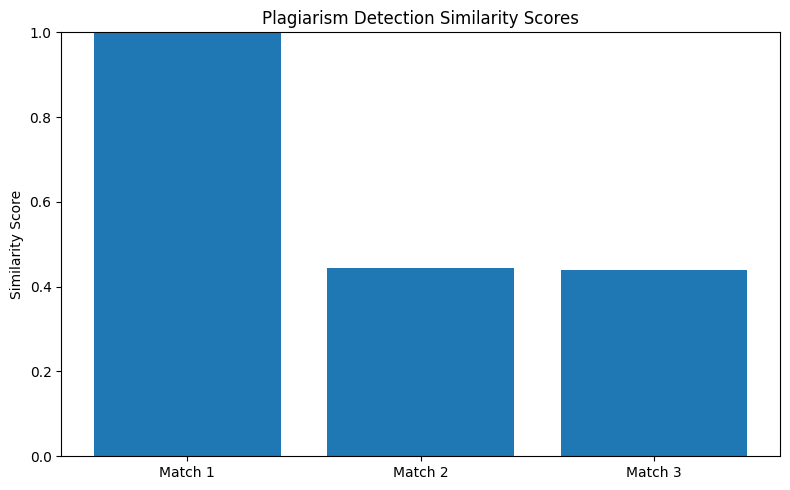

In [ ]:
from evaluation_utils import plot_plagiarism_scores

results = process_text("Paraphrasing tools help rewrite text while maintaining semantic consistency.", "plagiarism")["result"]
plot_plagiarism_scores(results)

# Create App


In [ ]:
# =========================
# 1) Install dependencies
# =========================
!pip install -q streamlit pyngrok fastapi uvicorn

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 9.2/9.2 MB 44.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 11.3/11.3 MB 69.1 MB/s eta 0:00:00


In [ ]:
# =========================
# 2) Add your ngrok authtoken
# =========================
NGROK_AUTH_TOKEN = "3CMHEMpiQuG9AvgTVQyMUc4R8EL_6RAygvPwj2qjfNChexacQ"

!ngrok config add-authtoken $NGROK_AUTH_TOKEN

Authtoken saved to configuration file: /root/.config/ngrok/ngrok.yml


In [ ]:
# =========================
# 3) Write app.py
# =========================
%%writefile app.py
import streamlit as st
import re
import faiss
import numpy as np
from transformers import pipeline, AutoTokenizer, AutoModelForSeq2SeqLM
from sentence_transformers import SentenceTransformer
from sklearn.metrics.pairwise import cosine_similarity

st.set_page_config(page_title="DocTrust", layout="wide")

# -------------------------
# Preprocessing
# -------------------------
def preprocess_text(text, max_chars=1500):
    text = re.sub(r'\s+', ' ', text).strip()
    return text[:max_chars]

# -------------------------
# Cache models so they load once
# -------------------------
@st.cache_resource
def load_models():
    summarizer = pipeline("summarization", model="facebook/bart-large-cnn")

    para_model_name = "Vamsi/T5_Paraphrase_Paws"
    para_tokenizer = AutoTokenizer.from_pretrained(para_model_name)
    para_model = AutoModelForSeq2SeqLM.from_pretrained(para_model_name)

    embedder = SentenceTransformer("all-MiniLM-L6-v2")

    corpus = [
        "Artificial intelligence improves healthcare systems by supporting diagnosis and treatment planning.",
        "Natural language processing allows machines to understand and generate human language.",
        "Students often struggle with summarizing long academic texts and preserving the main meaning.",
        "Paraphrasing tools help rewrite text while maintaining semantic consistency.",
        "Plagiarism detection systems compare text similarity to identify copied or reworded content."
    ]

    corpus_embeddings = embedder.encode(corpus)
    dimension = corpus_embeddings.shape[1]
    index = faiss.IndexFlatL2(dimension)
    index.add(np.array(corpus_embeddings))

    return summarizer, para_tokenizer, para_model, embedder, corpus, index

summarizer, para_tokenizer, para_model, embedder, corpus, index = load_models()

# -------------------------
# Modules
# -------------------------
def summarize(text, max_length=120, min_length=40, num_beams=4):
    result = summarizer(
        text,
        max_length=max_length,
        min_length=min_length,
        num_beams=num_beams,
        do_sample=False
    )
    return result[0]["summary_text"]

def compute_similarity(text_a, text_b):
    embeddings = embedder.encode([text_a, text_b])
    score = cosine_similarity([embeddings[0]], [embeddings[1]])[0][0]
    return float(score)

def paraphrase(text, num_candidates=3):
    input_text = "paraphrase: " + text + " </s>"

    encoding = para_tokenizer.encode_plus(
        input_text,
        return_tensors="pt",
        padding=True,
        truncation=True,
        max_length=256
    )

    outputs = para_model.generate(
        input_ids=encoding["input_ids"],
        attention_mask=encoding["attention_mask"],
        max_length=128,
        num_beams=1,
        do_sample=True,
        temperature=1.5,
        top_k=120,
        top_p=0.95,
        num_return_sequences=num_candidates
    )

    candidates = [
        para_tokenizer.decode(out, skip_special_tokens=True)
        for out in outputs
    ]

    query_emb = embedder.encode([text])
    cand_embs = embedder.encode(candidates)
    sims = cosine_similarity(query_emb, cand_embs)[0]

    valid = [(c, s) for c, s in zip(candidates, sims) if 0.70 <= s <= 0.97]
    if valid:
        best = min(valid, key=lambda x: x[1])
        return best[0]

    best_idx = int(sims.argmin())
    return candidates[best_idx]

def classify_plagiarism(score):
    if score >= 0.85:
        return "High Risk"
    elif score >= 0.70:
        return "Moderate Risk"
    return "Low Risk"

def check_plagiarism(text, k=3):
    query_embedding = embedder.encode([text])
    D, I = index.search(query_embedding, k=k)

    results = []
    for i, idx in enumerate(I[0]):
        similarity_score = 1 / (1 + D[0][i])
        results.append({
            "matched_text": corpus[idx],
            "similarity_score": round(float(similarity_score), 4),
            "risk_level": classify_plagiarism(similarity_score)
        })
    return results

def process_text(text, mode):
    text = preprocess_text(text)

    if not text:
        return {"error": "Input text is empty."}

    if len(text) < 20:
        return {"error": "Input text is too short. Please provide a longer text."}

    if mode == "summarize":
        return {"result": summarize(text)}

    elif mode == "paraphrase":
        para = paraphrase(text)
        sim = compute_similarity(text, para)
        return {
            "result": para,
            "similarity_score": round(sim, 4)
        }

    elif mode == "plagiarism":
        return {"result": check_plagiarism(text)}

    else:
        return {"error": "Invalid mode selected."}

# -------------------------
# UI
# -------------------------
st.title("📄 DocTrust — Academic Writing Assistance System")
st.write("An integrated NLP platform for summarization, paraphrasing, and plagiarism detection.")

text = st.text_area("Enter your academic text:", height=250)
mode = st.selectbox("Choose processing mode:", ["summarize", "paraphrase", "plagiarism"])

if st.button("Run"):
    response = process_text(text, mode)

    if "error" in response:
        st.error(response["error"])
    else:
        if mode == "summarize":
            st.subheader("Generated Summary")
            st.success(response["result"])

        elif mode == "paraphrase":
            st.subheader("Paraphrased Text")
            st.success(response["result"])
            st.info(f"Semantic Similarity Score: {response['similarity_score']}")

        elif mode == "plagiarism":
            st.subheader("Plagiarism Detection Results")
            for i, item in enumerate(response["result"], start=1):
                st.markdown(f"### Match {i}")
                st.write(item["matched_text"])
                st.write(f"**Similarity Score:** {item['similarity_score']}")
                st.write(f"**Risk Level:** {item['risk_level']}")
                st.write("---")

Writing app.py


In [ ]:
from pyngrok import ngrok

ngrok.kill()
url = ngrok.connect(8501)
print(url)

NgrokTunnel: "https://hatchling-awoke-overturn.ngrok-free.dev" -> "http://localhost:8501"


In [ ]:
# =========================
# 4) Run Streamlit in background
# =========================
!pkill streamlit
!streamlit run app.py --server.port 8501 --server.headless true &>/content/streamlit.log &

In [ ]:
# =========================
# 5) Open public tunnel
# =========================
from pyngrok import ngrok

# Clean old tunnels if any
for tunnel in ngrok.get_tunnels():
    ngrok.disconnect(tunnel.public_url)

public_url = ngrok.connect(8501)
print("Streamlit Public URL:", public_url)

Streamlit Public URL: NgrokTunnel: "https://hatchling-awoke-overturn.ngrok-free.dev" -> "http://localhost:8501"


In [ ]:
!pkill -f streamlit

In [ ]:
from pyngrok import ngrok

for tunnel in ngrok.get_tunnels():
    ngrok.disconnect(tunnel.public_url)